In [1]:
print("Inside 03_Exit_Text_Analysis.ipynb")

Inside 03_Exit_Text_Analysis.ipynb


Load Both Datasets

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from collections import Counter

from src.data_cleaning import full_clean_pipeline

sns.set(style="whitegrid")

# Load HRIS data
hris = full_clean_pipeline("../data/raw/hris_extract.csv")

# Load exit survey
exit_df = pd.read_csv("../data/raw/exit_survey.csv")

Basic Inspection

In [3]:
print(exit_df.head())
print("\n---------------------------------------------\n")
print(exit_df.info())

  Employee_ID                                     Exit_Statement
0     EMP0001  -  AFTER THLEE YEARS IN THE SAME ROLE, I FELT ...
1     EMP0003   I joined the company with high hopes for deve...
2     EMP0015                                                NaN
3     EMP0022                                                NaN
4     EMP0025  - Thxre was no structured development plan, an...

---------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Employee_ID     237 non-null    object
 1   Exit_Statement  104 non-null    object
dtypes: object(2)
memory usage: 3.8+ KB
None


How Many Attrition Employees?

In [4]:
attrition_ids = hris[hris["Attrition"] == 1]["Employee_ID"]

print("Total Attrition Employees:", len(attrition_ids))

Total Attrition Employees: 235


How Many Exit Survey Records?

In [5]:
print("Total Exit Survey Records:", exit_df["Employee_ID"].nunique())

Total Exit Survey Records: 237


Merge HRIS + Exit Survey

In [6]:
merged = hris.merge(
    exit_df,
    on="Employee_ID",
    how="left"
)

merged.head()

,Employee_ID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Exit_Statement
0,EMP0001,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,...,1,0,8,0,1,6,4,0,5,"- AFTER THLEE YEARS IN THE SAME ROLE, I FELT ..."
1,EMP0002,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,...,4,1,10,3,3,10,7,1,7,NaN
2,EMP0003,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,2,0,7,3,3,0,0,0,0,I joined the company with high hopes for deve...
3,EMP0004,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,...,3,0,8,3,3,8,7,3,0,NaN
4,EMP0005,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,1,6,3,3,2,2,2,2,NaN


Coverage Analysis

In [7]:
# Employees who left but have exit survey
exit_coverage = merged[merged["Attrition"] == 1]["Exit_Statement"].notna().mean()

print("Exit Survey Coverage (Leavers):", round(exit_coverage*100,2), "%")

Exit Survey Coverage (Leavers): 43.83 %


In [8]:
merged[merged["Attrition"] == 1]["Exit_Statement"].value_counts(dropna=False)

Exit_Statement
NaN                                                                                                                                                                                                                                                                                              132
blank                                                                                                                                                                                                                                                                                              5
- I WAS LOOKING FOR MENTORSHIP AND LEADERSHIP DEVELOPMENT ..  THE COMPANY LACKED STRUCTURED PROGRAMS FOR GROWTH ..  I’VE JOINED A FIRM THAT INVESTS IN ITS FUNURE LEADTRS ..                                                                                                                       2
I wanted to contribute to strategic planning and long-term visioy. My role was limimed to execution withou

Clean Exit Statements

In [9]:
# Remove missing or 'N/A'
clean_exit = merged[
    (merged["Attrition"] == 1) &
    (merged["Exit_Statement"].notna()) &
    (merged["Exit_Statement"].str.lower() != "n/a")
]

##### Basic Text Analysis

Clean Text and Word Frequency

In [10]:
# Combine all exit text
all_text = " ".join(clean_exit["Exit_Statement"].astype(str).str.lower())

# Remove punctuation
all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)

# Tokenize
words = all_text.split()

# Add custom HR stopwords
custom_stopwords = {
    "company", "role", "team", "work", "job",
    "employee", "also", "one", "would", "get",
    "like", "could", "even", "going"
}

stop_words = ENGLISH_STOP_WORDS.union(custom_stopwords)

# Remove stopwords and short words
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 3
]

# Top 20 words
common_words = Counter(filtered_words).most_common(20)

common_words

[('felt', 19),
 ('joined', 16),
 ('support', 15),
 ('accepted', 14),
 ('moved', 14),
 ('time', 13),
 ('didnt', 13),
 ('wanted', 11),
 ('despite', 9),
 ('career', 9),
 ('growth', 9),
 ('flexibility', 9),
 ('health', 9),
 ('focus', 9),
 ('development', 8),
 ('clear', 8),
 ('leaving', 8),
 ('learning', 8),
 ('years', 7),
 ('feel', 7)]

Word Cloud

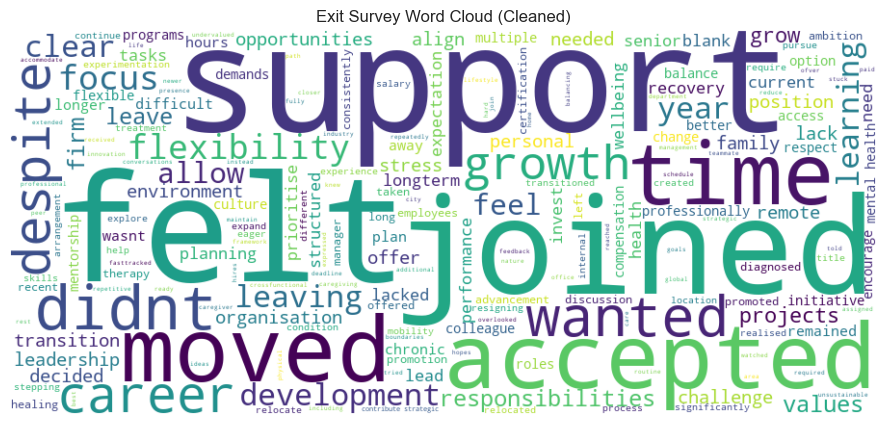

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

clean_text = " ".join(filtered_words)

wordcloud = WordCloud(
    width=900,
    height=400,
    background_color="white"
).generate(clean_text)

plt.figure(figsize=(12,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Exit Survey Word Cloud (Cleaned)")
plt.show()

Thematic Grouping (Manual Categorization)

In [12]:
def categorize_reason(text):
    text = text.lower()
    
    if "pay" in text or "salary" in text:
        return "Compensation"
    elif "manager" in text or "boss" in text:
        return "Manager"
    elif "worklife" in text or "balance" in text:
        return "Work-Life Balance"
    elif "growth" in text or "career" in text:
        return "Career Growth"
    elif "workload" in text or "hours" in text:
        return "Workload"
    else:
        return "Other"

clean_exit["Reason_Category"] = clean_exit["Exit_Statement"].apply(categorize_reason)

clean_exit["Reason_Category"].value_counts()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/3342726902.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_exit["Reason_Category"] = clean_exit["Exit_Statement"].apply(categorize_reason)


Reason_Category
Other                70
Career Growth        15
Compensation          7
Workload              4
Work-Life Balance     4
Manager               3
Name: count, dtype: int64

##### Exit Survey Insights

Text analysis of exit statements highlights recurring themes around career growth, development opportunities, flexibility, and perceived support.

While compensation and overtime emerged as strong quantitative predictors, qualitative feedback suggests employees are also motivated by long-term growth, learning opportunities, and work-life flexibility.

This indicates that attrition is driven not only by structural workload factors but also by engagement and development considerations.

Create Categorization Function

In [13]:
def categorize_exit_reason(text):
    
    text = str(text).lower()
    
    if any(word in text for word in ["career", "growth", "promotion", "development", "learning", "opportunity"]):
        return "Career Growth"
    
    elif any(word in text for word in ["salary", "pay", "compensation", "income"]):
        return "Compensation"
    
    elif any(word in text for word in ["balance", "flexibility", "hours", "overtime", "schedule"]):
        return "Work-Life Balance"
    
    elif any(word in text for word in ["manager", "boss", "leadership", "supervisor"]):
        return "Manager / Leadership"
    
    elif any(word in text for word in ["support", "culture", "environment", "team"]):
        return "Culture / Support"
    
    elif any(word in text for word in ["health", "stress", "burnout"]):
        return "Health / Stress"
    
    else:
        return "Other"

Apply Categorization

In [14]:
clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)

theme_counts = clean_exit["Theme"].value_counts()

theme_counts

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/3765675320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)


Theme
Career Growth           30
Other                   23
Culture / Support       19
Work-Life Balance       16
Health / Stress          8
Compensation             5
Manager / Leadership     2
Name: count, dtype: int64

Convert to Percentage

In [15]:
theme_distribution = (theme_counts / theme_counts.sum()) * 100

theme_distribution

Theme
Career Growth           29.126214
Other                   22.330097
Culture / Support       18.446602
Work-Life Balance       15.533981
Health / Stress          7.766990
Compensation             4.854369
Manager / Leadership     1.941748
Name: count, dtype: float64

Visualize

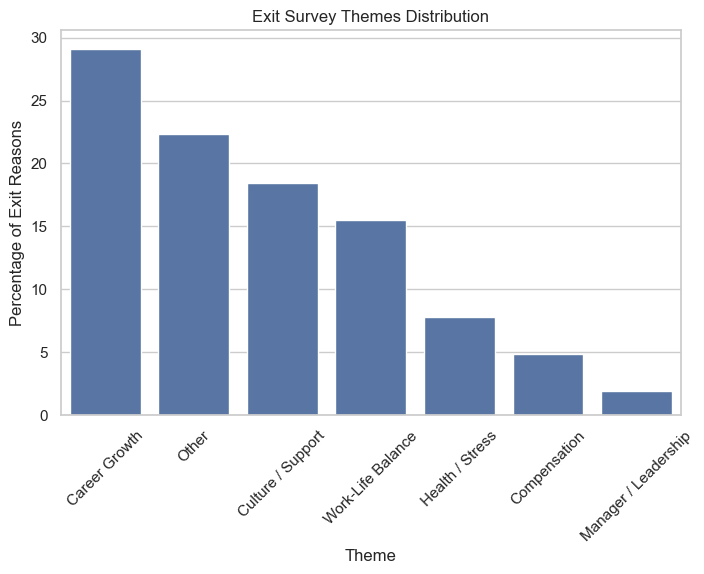

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=theme_distribution.index,
    y=theme_distribution.values
)

plt.xticks(rotation=45)
plt.ylabel("Percentage of Exit Reasons")
plt.title("Exit Survey Themes Distribution")
plt.show()

##### Integrated Attrition Insights (Quantitative + Qualitative)

Exit survey analysis reveals that career growth (29%), culture/support (18%), and work-life balance (15%) are the most frequently cited reasons for leaving.

These findings strongly align with the predictive model, which identified overtime, engagement metrics, and tenure stability as the strongest statistical drivers of attrition.

Interestingly, compensation is cited less frequently (5%), suggesting that turnover is driven more by growth opportunities and workload balance than purely financial dissatisfaction.

The alignment between quantitative and qualitative insights increases confidence that attrition is structurally driven by workload intensity, career progression constraints, and engagement factors.

Ensure We Have Merged Data

In [17]:
# Merge HRIS + Exit Survey
merged = hris.merge(
    exit_df,
    on="Employee_ID",
    how="left"
)

# Keep only leavers with valid exit statements
clean_exit = merged[
    (merged["Attrition"] == 1) &
    (merged["Exit_Statement"].notna()) &
    (merged["Exit_Statement"].str.lower() != "n/a")
]

# Apply theme categorization
clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/313870450.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)


Exit Themes by Department

Distribution by Department

In [18]:
dept_theme = (
    clean_exit
    .groupby(["Department", "Theme"])
    .size()
    .unstack(fill_value=0)
)

dept_theme_pct = dept_theme.div(dept_theme.sum(axis=1), axis=0) * 100

dept_theme_pct

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/2956669600.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Department", "Theme"])


Theme,Career Growth,Compensation,Culture / Support,Health / Stress,Manager / Leadership,Other,Work-Life Balance
Department,,,,,,,
Human Resources,50.000000,0.000000,25.000000,0.000000,0.000000,0.000000,25.000000
Research & Development,35.087719,1.754386,17.543860,8.771930,1.754386,19.298246,15.789474
Sales,19.047619,9.523810,19.047619,7.142857,2.380952,28.571429,14.285714


Visualize (Sales vs R&D)

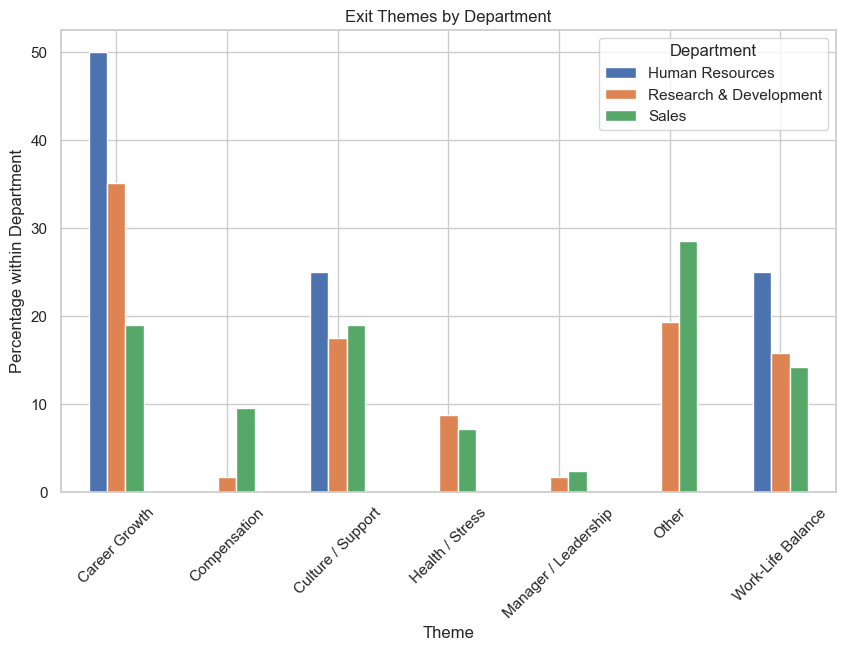

In [19]:
dept_theme_pct.T.plot(kind="bar", figsize=(10,6))
plt.ylabel("Percentage within Department")
plt.title("Exit Themes by Department")
plt.xticks(rotation=45)
plt.show()

Exit Themes by Job Level

Group by Job Level

In [20]:
joblevel_theme = (
    clean_exit
    .groupby(["JobLevel", "Theme"])
    .size()
    .unstack(fill_value=0)
)

joblevel_theme_pct = joblevel_theme.div(joblevel_theme.sum(axis=1), axis=0) * 100

joblevel_theme_pct

Theme,Career Growth,Compensation,Culture / Support,Health / Stress,Manager / Leadership,Other,Work-Life Balance
JobLevel,,,,,,,
1,35.087719,7.017544,14.035088,7.017544,3.508772,19.298246,14.035088
2,25.000000,4.166667,12.500000,8.333333,0.000000,25.000000,25.000000
3,26.666667,0.000000,40.000000,6.666667,0.000000,20.000000,6.666667
4,0.000000,0.000000,50.000000,25.000000,0.000000,25.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,66.666667,33.333333


Visualize

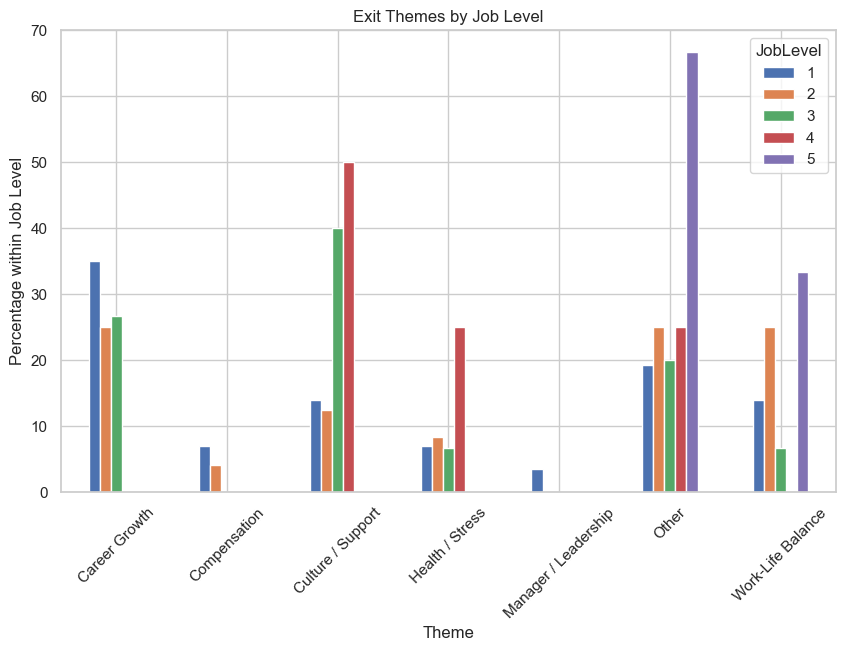

In [21]:
joblevel_theme_pct.T.plot(kind="bar", figsize=(10,6))
plt.ylabel("Percentage within Job Level")
plt.title("Exit Themes by Job Level")
plt.xticks(rotation=45)
plt.show()

##### Segment-Level Attrition Insights

Exit themes vary meaningfully across departments and job levels.

* Junior employees (Level 1) primarily cite career growth as the main reason for leaving.

* R&D attrition is largely development and engagement-driven.

* Sales attrition reflects a more mixed profile including workload, compensation, and cultural factors.

* Compensation overall is cited infrequently, suggesting turnover is more structurally driven by growth opportunities and workload balance rather than pure pay dissatisfaction.

These findings align strongly with predictive model outputs, reinforcing that attrition is multi-dimensional and segment-specific.

Inspect “Other” Manually

In [22]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

clean_exit.loc[
    clean_exit["Theme"] == "Other",
    ["Employee_ID", "Exit_Statement"]
].head(20)

others = clean_exit[clean_exit["Theme"] == "Other"]["Exit_Statement"]

for i, statement in enumerate(others.head(20), 1):
    print(f"\n--- Statement {i} ---")
    print(statement)


--- Statement 1 ---
My partxer was recently diagnosed with a serious illness, and I’ve bwcome their primary caregiver. Balancing work and medecal appointments has proren unsustainable. I need to step away to suwport my family during this critical time. 

--- Statement 2 ---
blank

--- Statement 3 ---
AFLER YEARS IN THE SAME DEPARTMENT, I FELT READY FOR A NEW CHALLENGE ..  UNFYRTUNATELY, INTERNAL MOBILITY WAS SLOW AND LACKED TRANSPARXNCY ..  I ACCEPTED AN OFFER THAT ALLOWS ME TO LEAD INITIATHVES AND EXPAND MY SKHLLSET ..  

--- Statement 4 ---
WE DECIDED TO MOVE TO A QUIEYER AREA FOR OUR CHILDREN’S SCHOOLING AND WELLBEING. THE COMPANY DIDH’T HAVE A PRESENCE IN THAT REGION. I’VE JOINED A LOCAL ORGANISATION THAT ALIGNS WITH OUR LIFEMTYLE.

--- Statement 5 ---
While I’ve appreciated my time here, I’ve always dreamed of starzing my own business. I’m leaving to pursue an entrepreneurial venture in the food industry, something I’ve been planning for years. It’s a leap of faith, but one I fee

Updated Themes

In [23]:
def categorize_exit_reason(text):
    
    text = str(text).lower()
    
    # External reasons
    if any(word in text for word in [
        "move", "relocat", "family", "caregiver",
        "partner", "health condition", "treatment",
        "entrepreneur", "own business", "nonprofit",
        "personal reason", "schooling"
    ]):
        return "External / Personal"
    
    # Career growth
    elif any(word in text for word in [
        "career", "growth", "promotion", "development",
        "learning", "opportunity", "mobility"
    ]):
        return "Career Growth"
    
    # Compensation
    elif any(word in text for word in [
        "salary", "pay", "compensation", "raise"
    ]):
        return "Compensation"
    
    # Work-life balance
    elif any(word in text for word in [
        "balance", "flexibility", "hours", "overtime", "remote"
    ]):
        return "Work-Life Balance"
    
    # Manager
    elif any(word in text for word in [
        "manager", "boss", "leadership", "supervisor"
    ]):
        return "Manager / Leadership"
    
    # Culture
    elif any(word in text for word in [
        "support", "culture", "environment", "values"
    ]):
        return "Culture / Support"
    
    # Health
    elif any(word in text for word in [
        "stress", "burnout"
    ]):
        return "Health / Stress"
    
    else:
        return "Other"

In [24]:
clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)

theme_counts = clean_exit["Theme"].value_counts()

theme_counts

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/3765675320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_exit["Theme"] = clean_exit["Exit_Statement"].apply(categorize_exit_reason)


Theme
External / Personal     37
Career Growth           23
Other                   15
Culture / Support        9
Work-Life Balance        7
Compensation             5
Health / Stress          5
Manager / Leadership     2
Name: count, dtype: int64

In [25]:
theme_distribution = (theme_counts / theme_counts.sum()) * 100

theme_distribution

Theme
External / Personal     35.922330
Career Growth           22.330097
Other                   14.563107
Culture / Support        8.737864
Work-Life Balance        6.796117
Compensation             4.854369
Health / Stress          4.854369
Manager / Leadership     1.941748
Name: count, dtype: float64

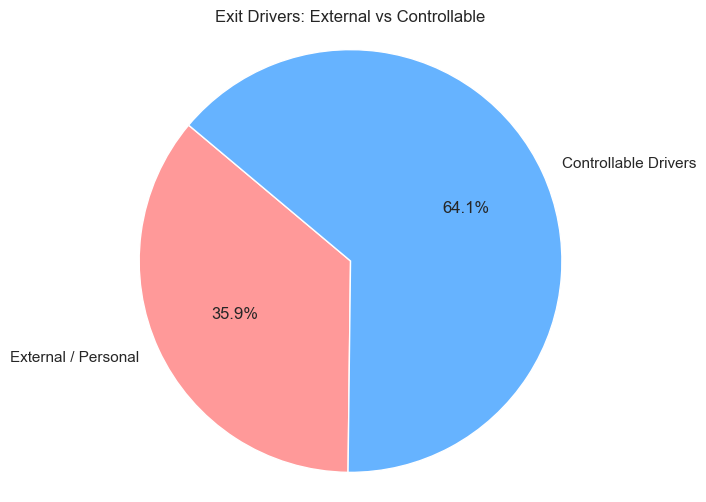

In [26]:
# Calculate totals
external_pct = theme_distribution["External / Personal"]

controllable_pct = 100 - external_pct

# Create new aggregated data
pie_labels = ["External / Personal", "Controllable Drivers"]
pie_values = [external_pct, controllable_pct]

# Plot
plt.figure(figsize=(6,6))
plt.pie(
    pie_values,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#FF9999", "#66B3FF"]
)

plt.title("Exit Drivers: External vs Controllable")
plt.axis("equal")
plt.show()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_5032/2665798090.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


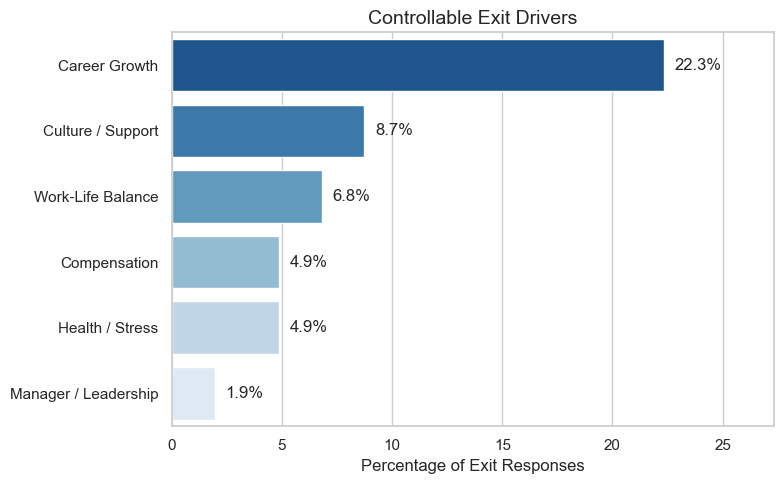

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Exclude External and Other
controllable_themes = theme_distribution.drop(
    labels=["External / Personal", "Other"],
    errors="ignore"
)

# Sort descending for clean executive display
controllable_themes = controllable_themes.sort_values(ascending=False)

# Convert to DataFrame for seaborn
controllable_df = controllable_themes.reset_index()
controllable_df.columns = ["Theme", "Percentage"]

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=controllable_df,
    x="Percentage",
    y="Theme",
    palette="Blues_r"
)

# Add percentage labels
for index, value in enumerate(controllable_df["Percentage"]):
    plt.text(value + 0.5, index, f"{value:.1f}%", va="center")

plt.title("Controllable Exit Drivers", fontsize=14)
plt.xlabel("Percentage of Exit Responses")
plt.ylabel("")
plt.xlim(0, controllable_df["Percentage"].max() + 5)

plt.tight_layout()
plt.show()

##### Exit Survey – Refined Insights

A significant portion of exits (36%) are driven by external life transitions such as relocation, caregiving, entrepreneurship, or career changes. These exits are largely non-controllable.

Among controllable internal drivers, career growth emerges as the primary reason for leaving, followed by engagement and work-life balance factors.

Compensation is cited less frequently, suggesting attrition is more structurally linked to development opportunities and workload balance than pay dissatisfaction.